In [1]:
import pandas as pd 

In [34]:
df = pd.read_csv('movie.csv')
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [35]:
df.shape

(40000, 2)

In [36]:
import seaborn as sns 
from matplotlib import pyplot as plt 

<Axes: xlabel='label'>

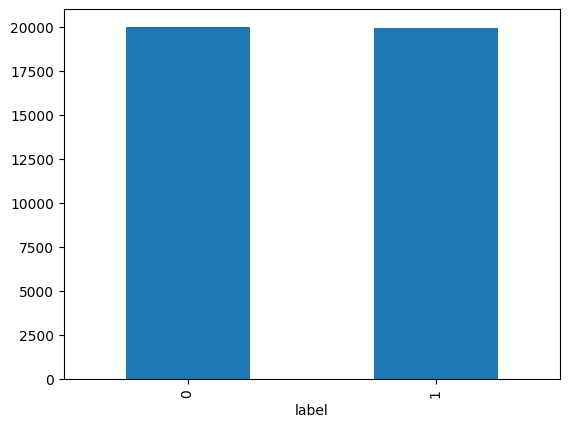

In [37]:
df['label'].value_counts().plot(kind = 'bar')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


### Data Preprocessing

In [39]:
import string 
eng_punc_list = string.punctuation
eng_punc_list

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
!pip -q install contractions

In [40]:
import contractions
temp = "I'll be there within 5 min. Shouldn't you be there too?"
expand_words = []
for word in temp.split(): 
    expand_words.append(contractions.fix(word))

" ".join(expand_words)

'I will be there within 5 min. Should not you be there too?'

In [41]:
import string
eng_punc_list = string.punctuation
def text_normalization(text: str):
    # convert into lower case 
    text = text.lower()
    # remove functuations
    translator = str.maketrans('' , '' , eng_punc_list)
    text = text.translate(translator)
    # expand contractions 
    expand_words = []
    for word in text.split(): 
        expand_words.append(contractions.fix(word))

    text = " ".join(expand_words)
    return text

In [42]:
df['text'] = df['text'].apply(text_normalization)

In [ ]:
# Normalize numbers 
import spacy
from word2number import w2n

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
def normalize_numbers(text):
    doc = nlp(text)
    tokens = []
    i = 0

    while i < len(doc):
        token = doc[i]
        if token.like_num and token.text.isalpha():
            phrase = token.text
            j = i + 1
            while j < len(doc) and doc[j].text.isalpha():
                phrase += " " + doc[j].text
                j += 1
            try:
                tokens.append(str(w2n.word_to_num(phrase)))
                i = j
            except:
                tokens.append(token.text)
                i += 1
        else:
            tokens.append(token.text)
            i += 1

    return " ".join(tokens)

In [43]:
df.head()

,text,label
0,i grew up b 1965 watching and loving the thund...,0
1,when i put this movie in my dvd player and sat...,0
2,why do people who do not know what a particula...,0
3,even though i have great interest in biblical ...,0
4,i am a die hard dads army fan and nothing will...,1


In [ ]:
!pip -q install nltk 

### Tokenize the text

In [44]:
df.head()

,text,label
0,i grew up b 1965 watching and loving the thund...,0
1,when i put this movie in my dvd player and sat...,0
2,why do people who do not know what a particula...,0
3,even though i have great interest in biblical ...,0
4,i am a die hard dads army fan and nothing will...,1


In [45]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [46]:
# Use WordPiece or BPE model
tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

In [47]:
# Trainer
from tokenizers.trainers import WordPieceTrainer
trainer = WordPieceTrainer(vocab_size=10000, special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"])

In [48]:
tokenizer.train_from_iterator(iterator = df['text'] , trainer = trainer)

### Encode each sentence into token ids

In [49]:
def encode_sentence(sentence): 
    return tokenizer.encode(sentence).ids

In [50]:
df['token_ids'] = df['text'].apply(encode_sentence)

### Pad sequences for model input

In [51]:
MAX_LEN = 200
PAD_ID = tokenizer.token_to_id("[PAD]")

def pad_sequence(ids , max_len = MAX_LEN): 
    ids = ids[ : max_len]
    ids += [PAD_ID] * (max_len - len(ids))
    return ids 

In [52]:
df['padded_token_ids'] = df['token_ids'].apply(pad_sequence)

In [53]:
df.head()

,text,label,token_ids,padded_token_ids
0,i grew up b 1965 watching and loving the thund...,0,"[24, 4826, 419, 17, 2636, 152, 744, 222, 3988,...","[24, 4826, 419, 17, 2636, 152, 744, 222, 3988,..."
1,when i put this movie in my dvd player and sat...,0,"[420, 24, 918, 249, 288, 231, 408, 1063, 4255,...","[420, 24, 918, 249, 288, 231, 408, 1063, 4255,..."
2,why do people who do not know what a particula...,0,"[686, 299, 530, 330, 299, 253, 529, 399, 16, 2...","[686, 299, 530, 330, 299, 253, 529, 399, 16, 2..."
3,even though i have great interest in biblical ...,0,"[440, 760, 24, 301, 487, 719, 231, 3234, 2744,...","[440, 760, 24, 301, 487, 719, 231, 3234, 2744,..."
4,i am a die hard dads army fan and nothing will...,1,"[24, 386, 16, 1929, 828, 2777, 129, 3113, 1116...","[24, 386, 16, 1929, 828, 2777, 129, 3113, 1116..."


In [54]:
from sklearn.model_selection import train_test_split
train_data , test_data = train_test_split(df , test_size = 0.3 , random_state = 42)
validation_data , test_data = train_test_split(test_data , test_size = 0.5 , random_state = 42)

In [55]:
train_data.shape , test_data.shape , validation_data.shape

((28000, 4), (6000, 4), (6000, 4))

In [56]:
train_data.drop(columns = ['text' , 'token_ids'] , axis = 1, inplace = True)
test_data.drop(columns = ['text' , 'token_ids'] , axis = 1, inplace = True)
validation_data.drop(columns = ['text' , 'token_ids'] , axis = 1, inplace = True)

In [57]:
train_data.head()

,label,padded_token_ids
38015,0,"[1379, 1281, 1379, 235, 3933, 408, 5359, 388, ..."
2281,1,"[420, 24, 533, 912, 249, 276, 235, 266, 388, 2..."
36629,0,"[249, 288, 233, 374, 2418, 16, 2529, 1564, 226..."
6087,0,"[2530, 209, 1514, 233, 1349, 225, 240, 359, 89..."
11792,1,"[1269, 4610, 146, 1326, 266, 661, 773, 1768, 1..."


In [58]:
print(train_data['padded_token_ids'].isnull().sum())

0


### Make dataset and dataloader

In [59]:
import torch
from torch.utils.data import Dataset, DataLoader

In [80]:
class TextDataset(Dataset): 
    def __init__(self, df, pad_id, max_len):
        self.pad_id = pad_id
        self.max_len = max_len

        # Clean and fix sequences
        def fix_sequence(seq):
            # Replace None with pad_id and cast to int
            seq = [int(x) if x is not None else pad_id for x in seq]
            # Truncate or pad
            if len(seq) > max_len:
                return seq[:max_len]
            else:
                return seq + [pad_id] * (max_len - len(seq))

        self.padded_token_ids = [fix_sequence(seq) for seq in df['padded_token_ids']]
        self.labels = df['label'].astype(int).tolist()

    def __len__(self): 
        return len(self.labels)

    def __getitem__(self, index): 
        # Convert to tensors here (avoids multiprocessing issues)
        return torch.tensor(self.padded_token_ids[index], dtype=torch.long), \
               torch.tensor(self.labels[index], dtype=torch.long)

In [83]:
train_dataset = TextDataset(train_data , max_len = 200, pad_id = PAD_ID)
test_dataset = TextDataset(test_data, max_len = 200, pad_id = PAD_ID)
validation_dataset = TextDataset(validation_data, max_len = 200, pad_id = PAD_ID)

In [84]:
train_data_loader = DataLoader(
    dataset = train_dataset, 
    batch_size = 32,
    pin_memory=True
)
test_data_loader = DataLoader(
    dataset = test_dataset, 
    batch_size = 32, 
    pin_memory = True 
)
validation_data_loader = DataLoader(
    dataset = validation_dataset, 
    batch_size = 32, 
    pin_memory = True 
)

### Define the Model 

In [63]:
feature , label = train_dataset[0]
feature.shape

torch.Size([200])

In [64]:
PAD_ID

0

In [65]:
import torch.nn as nn

In [100]:
class LSTMClassifier(nn.Module): 
    def __init__(self , vocab_size , embedding_dim, hidden_size, num_layes, pad_idx):
         super().__init__()
         self.embedding = nn.Embedding(
             num_embeddings = vocab_size, 
             embedding_dim = embedding_dim, 
             padding_idx = pad_idx, 
         )
         self.lstm = nn.LSTM(
             embedding_dim, hidden_size, 
             num_layers=num_layers, batch_first = True
         )
         self.fc = nn.Linear(hidden_size, 1)
         

    def forward(self , x): 
        x = self.embedding(x)
        output , (h_n , c_n) = self.lstm(x)
        h_last = h_n[-1] # use the last hidden state value
        logits = self.fc(h_last)
        return logits

In [101]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [102]:
vocab_size = tokenizer.get_vocab_size()
embedding_dim = 128
hidden_size = 256
num_layers = 1
model = LSTMClassifier(vocab_size, embedding_dim, hidden_size, num_layers, PAD_ID)
model.to(device)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [95]:
import torch.optim as optim

In [96]:
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters() , lr = 1e-3)

In [99]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()  
    total_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_features, batch_labels in train_data_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device).float().unsqueeze(1)  

        optimizer.zero_grad()          
        outputs = model(batch_features)  

        loss = criterion(outputs, batch_labels)  
        loss.backward()              
        optimizer.step()              

        total_train_loss += loss.item() * batch_features.size(0)

        # training accuracy
        predicted_train = (torch.sigmoid(outputs) > 0.5).long()
        train_correct += (predicted_train == batch_labels.long()).sum().item()
        train_total += batch_labels.size(0)

    avg_train_loss = total_train_loss / len(train_data_loader.dataset)
    train_acc = train_correct / train_total
    print(f"Epoch {epoch+1}/{EPOCHS}, Training Loss: {avg_train_loss:.4f}, Training Acc: {train_acc:.4f}")

    # ---------------- Validation ----------------
    model.eval()  
    total_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for batch_features, batch_labels in validation_data_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device).float().unsqueeze(1)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            total_val_loss += loss.item() * batch_features.size(0)

            predicted = (torch.sigmoid(outputs) > 0.5).long()
            correct += (predicted == batch_labels.long()).sum().item()
            total += batch_labels.size(0)

    avg_val_loss = total_val_loss / len(validation_data_loader.dataset)
    val_accuracy = correct / total

    print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}\n")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [91]:
train_data['label'].unique()

array([0, 1], dtype=int64)